# SOK-1303 Mikroøkonomi
## Notater Markededsteori, økonomisk politikk - kapittel 10


Her skal vi se på virkningen av å innføre en avgift per solgte enhet. En skatt lik $t$ per solgt enhet i markedet skaper en "kile" mellom prisen konsumentene betaler ($P^E$) og den produsentene mottar ($P^T$):
$$P^E=P^T+t\tag{1}$$

Dette kan vi vise med følgende eksempel:
Vi skal se på et markedet der etterspørselen er gitt ved
$$Q^E=500-3.2P\tag{2}$$
 

og tilbudet er lik:
$$Q^T=-100+4.3P\tag{3}$$
 

Om avgiften på $t$ kr per enhet betales av selgeren, da vil selger ha en pris på $P$ per enhet fra kjøperen og av dette må kroner $t$ sendes videre til myndighetene; da får selgeren $(P-t)$kr per enhet solgt.

Dersom en avgift på $T$ per enhet må betales av kjøperen, må han betale $P$ til selgeren pluss $T$ til myndighetene, altså $P+t)$ tilsammen. Vi kan da skrive etterspørsel og tilbud som følgende: 

 $$Q^E=500-3.2(P+T)\tag{4}$$

og tilbud:
$$Q^T=-100+4.3(P-t)\tag{5}$$

La oss sette opp våre funksjoner:

In [1]:
# importer pakkene
import numpy as np
from matplotlib import pyplot as plt
import sympy as sp

In [31]:
 #Etterspørsel i likning (4)

def Q_E(P,T):
    return 500 - 3.2*(P+T)

#Tilbud i likning (5)

def Q_T(P,t):
    return -100+4.3*(P-t)

La oss tegne eksempelet med en avgift på 4 kr lagt på produsenter.

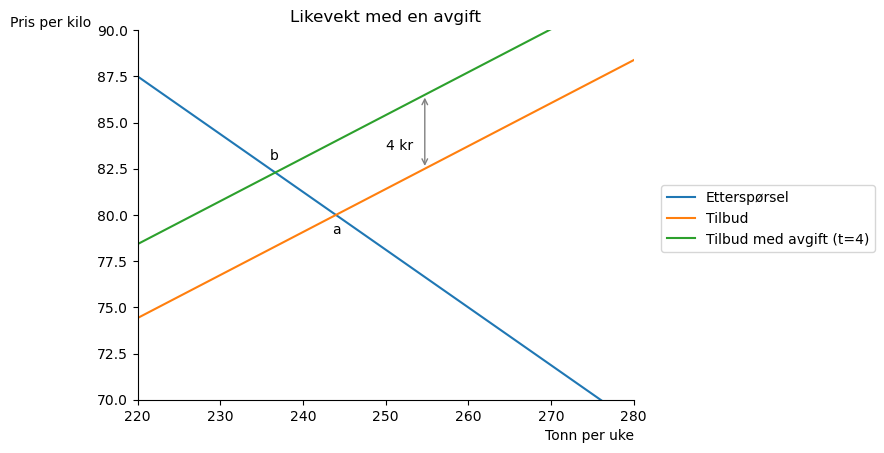

In [14]:
p_num=np.linspace(0.1,300,100)

#lag en akse

def create_ax():
                fig, ax = plt.subplots()
                ax.set_ylabel('Pris per kilo', loc='top', rotation = 0)
                ax.set_xlabel('Tonn per uke', loc='right')
                ax.set(xlim=(220,280))
                ax.set(ylim=(70,90))
                ax.spines['top'].set_color('none')
                ax.spines['right'].set_color('none')
                
                return fig, ax

fig, ax = create_ax()

# plott funksjonene

ax.plot(Q_E(p_num, 0),p_num, label='Etterspørsel')

ax.plot(Q_T(p_num, 0),p_num, label='Tilbud')
ax.plot(Q_T(p_num, 4),p_num, label='Tilbud med avgift (t=4)')

# vis avstand mellom linjene

ax.text(250, 83.5, "4 kr")

ax.annotate("", (Q_T(82.5,0),82.5), (Q_T(86.5,4), 86.5), arrowprops={"arrowstyle":"<->", "color":"gray"})

# Vis likevektskvantum før og etter
ax.text(243.5, 79, "a")
ax.text(236, 83, "b")

# tittel
ax.set_title('Likevekt med en avgift')

#vis navnene utenfor plottet:

ax.legend(bbox_to_anchor=(1.5,0.6));

Den opprinnelige likevekten er i a. Den nye tilbudsfunskjonen krysser etterspørsel i b og vi ser at omsatt mengde faller. Før vi beregner effekten på likevekten, la oss spørre hva som ville skjedd dersom vi hadde lagt avgiften på kjøperne?

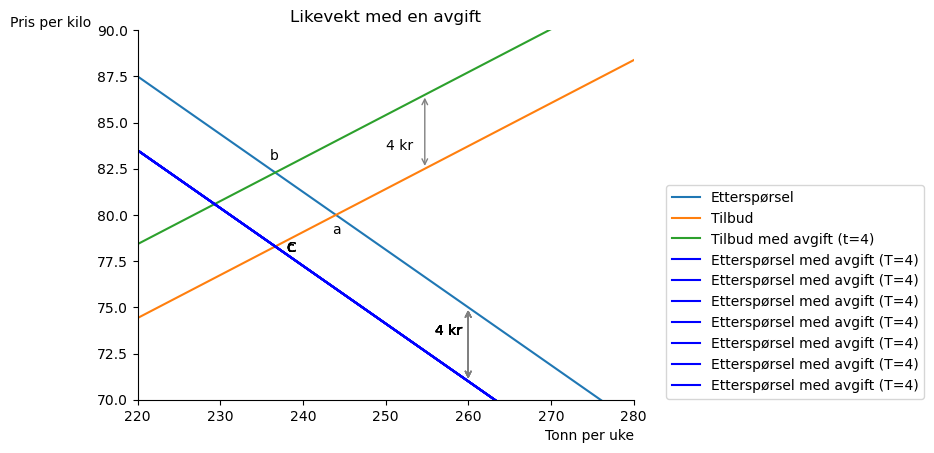

In [24]:
ax.plot(Q_E(p_num,4),p_num, label='Etterspørsel med avgift (T=4)', color='blue')
ax.text(238, 78, "c")

ax.text(256, 73.5, "4 kr")

ax.annotate("", (Q_E(75,0),75), (Q_E(71,4), 71), arrowprops={"arrowstyle":"<->", "color":"gray"})
ax.legend(bbox_to_anchor=(1.6,0.6))
fig

Det ser ut som om omstatt kvantum blir det samme om vi ilegge avgiften kjøpere eller selgere! La oss løse for likevekten og vise dette formelt.

In [32]:
# definer symboler i sympy

Q,P,T,t=sp.symbols('Q P T t', positive=True, real=True)

# betingelse for likevekt

eq_cond=sp.Eq(Q_E(P,T),Q_T(P,t))
eq_cond

Eq(-3.2*P - 3.2*T + 500, 4.3*P - 4.3*t - 100)

In [33]:
# løs for P
P_eq=sp.solve(eq_cond,P)
P_eq[0]

-0.426666666666667*T + 0.573333333333333*t + 80.0

In [34]:
# finn tilsvarende kvantum
Q_eq=Q_T(P_eq[0],t)
Q_eq

-1.83466666666667*T - 1.83466666666667*t + 244.0

Legg merke til at vi ser samme tall foran T (avgift lagt på kjøper) og t (avgift lagt på selger). Det er dette vi oppdaget i figuren. En avgift på 4 kr på selger eller kjøper har samme effekt på likevektskvantumet!

In [38]:
# Bruk sp.lambdify for å gjøre om sympy til numpy array

# Likevektspris som funksjon av t og T

P_eq_fn=sp.lambdify(
    (t,T), 
    P_eq[0]
)

P_eq_fn(t,T)

-0.426666666666667*T + 0.573333333333333*t + 80.0

Dette ser det samme ut som før, men vi har nå laget en funksjon av t og T som vi kan plotte med numpy i matplotlib.

In [39]:
# Likevektskvantum som funksjon av t og T

Q_eq_fn=sp.lambdify(
    (t,T), 
    Q_eq
)

Q_eq_fn(t,T)

-1.83466666666667*T - 1.83466666666667*t + 244.0

In [40]:
# Kvantum omsatt med avgift på selger på t=4
Q_eq_fn(4,0)

236.66133333333332

In [41]:
# Kvantum omsatt med avgift på kjøper på T=4
Q_eq_fn(0,4)

236.66133333333332

Kvantum er det samme uansett hvem som må betale avgiften.

In [42]:
Q_opt = round(Q_eq_fn(4,0),2)
Q_opt

236.66

In [49]:
# prisen som konsumenten må betale er
P_E = round(P_eq_fn(4,0),2)
P_E

82.29

In [50]:
# prisen som produsenten får er
P_E -4

78.29

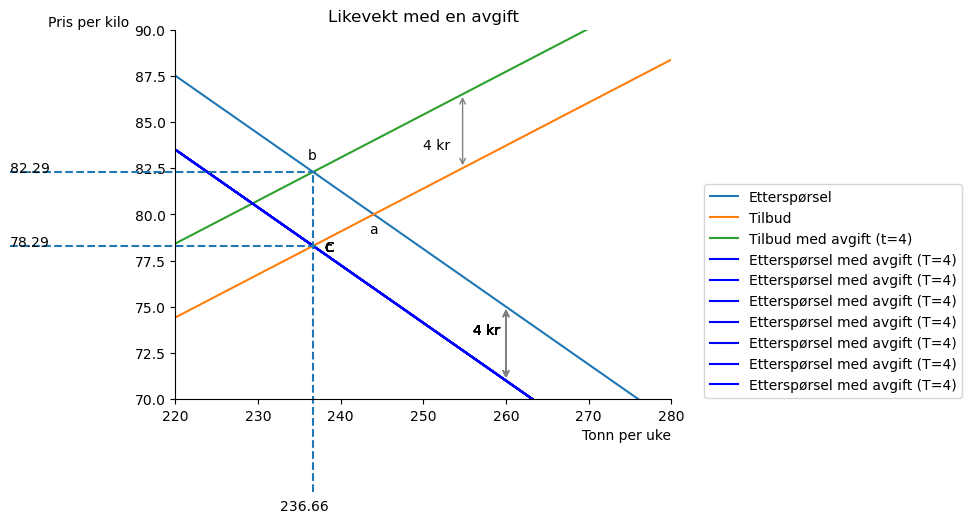

In [52]:
# sett inn linjer som viser likevekten
# clip_on=False for å tegne utenfor plottområdet

ax.vlines(Q_eq_fn(4,0),65, P_E, linestyles='dashed', clip_on=False)
ax.hlines(P_eq_fn(0,4),200,237, linestyles='dashed', clip_on=False)
ax.hlines(P_eq_fn(4,0),200,237, linestyles='dashed', clip_on=False)

# sett inn likevektsverdier i figuren

ax.annotate(Q_opt, xy=(Q_opt-4,64), annotation_clip=False)
ax.annotate(P_E, xy=(200, P_E), annotation_clip=False)
ax.annotate(P_E-4, xy=(200, P_E-4), annotation_clip=False)

ax.legend(bbox_to_anchor=(1.6,0.6))
fig

In [56]:
P_a = P_eq_fn(0,0)
P_a

80.0

Vi ser at avgiften driver en kile mellom prisen som kjøper betaler $P_E$, og det som produsenten mottar $P_T$. Konsumentene betaler totalt 82.29 kr og produsentene får 78.29 kr. Forskjellen mellom disse er avgiften som betales til staten. Før avgiften ble innført var markedet i likevekt i punkt a,  her betalte konsumenter 80 kr og alt gikk til selgere.

## Hvilken side av markedet betaler mest av avgiften?
Før avgiften ble innført er markedet i punkt a, og prisen er på 80 kr per kilo. Etter at avgiften på 4 kr blir innført øker prisen som konsumenter betaler med 2.29kr mens produsenter får 1.71 kr per kilo mindre betalt. Konsumenter betaler $\frac{2.29}{4} *100% $= $57.25%$ av avgiften mens produsenter betaler 42.75%.

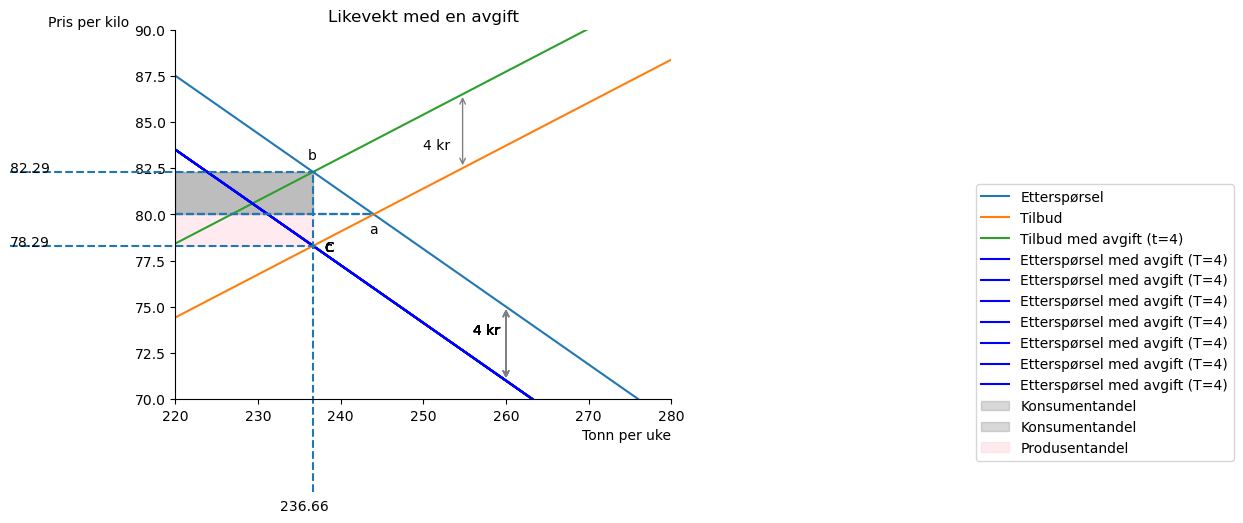

In [58]:
# vi kan illustrere hvem som betaler hva av avgiften

q=np.linspace (220, Q_eq_fn(4,0), 100)


ax.hlines(P_eq_fn(0,0),220,Q_eq_fn(0,0), linestyles='dashed')

ax.fill_between(q,P_E,P_a, color = "gray", alpha = 0.3, label='Konsumentandel')
ax.fill_between(q,P_a,P_E-4, color = "pink", alpha = 0.3, label='Produsentandel')

ax.legend(bbox_to_anchor=(1.6,0.6))
fig

Totalt avgiftproveny til staten er summen av det rosa og det grå området i figuren. Vi ser at konsumentene betaler mest. Vi kan lage en hypotese om at det er den siden av markedet som er minst prisfølsom som vil betale mest. Hvis dette stemmer må det være tilfellet at selgere reagerer mer på prisendringer enn konsumenter, målt fra den opprinnelige likevekten.

## En optimal avgiftssats?
Vi kan tenke oss at myndighetene har forskjellige mål med avgiftspolitikken. Noen avgifter legges på varer som myndighetene vil at vi skal bruke mindre av, for eksempel alkohol, usunn mat og bilkjøring. Disse gir samtidig inntekter til myndighetene. Flere ganger har Tenk Tromsø vurdert om bompengeavgiften i Tromsø bør økes fordi inntektene er lavere enn forventet.

Vi kan beregne for eksempel en avgiftssats i et marked som maksimerer avgiftprovenyet. I den siste figuren ser vi at avgiftproveny er avgiften per enhet multiplisert med antall enheter solgt. La oss undersøke dette for en avgift lagt på produsenten (dvs T=0). La oss først undersøke effekten som en avgift har på omsetningen.

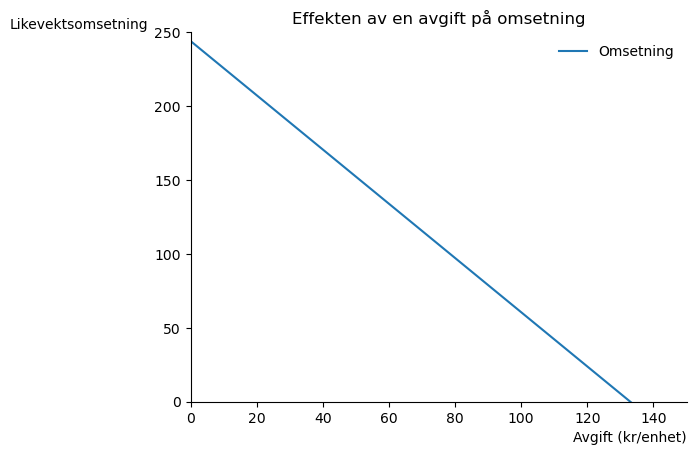

In [59]:
t_num=np.linspace(0,150,100)


fig,ax=plt.subplots()

ax.set_ylabel('Likevektsomsetning', loc = 'top', rotation = 0)
ax.set_xlabel('Avgift (kr/enhet)', loc= 'right')

ax.spines['top'].set_color('none')
ax.spines['right'].set_color('none')

ax.plot(t_num, Q_eq_fn(t_num, 0),label='Omsetning')



#legend:
ax.legend(loc='best', frameon=False)

#title
ax.set_title ('Effekten av en avgift på omsetning')

ax.set_xlim(0,150)
ax.set_ylim(0,250);

Myndighetene står overfor en avveining her: en økning i avgiften gir flere kroner i proveny per enhet solgt, men reduserer samtidig antall enheter solgt. La oss undersøke dette næremere.

In [60]:
def avgiftprov(t):
    return t*Q_eq_fn(t,0)
avgiftprov(t)

t*(244.0 - 1.83466666666667*t)

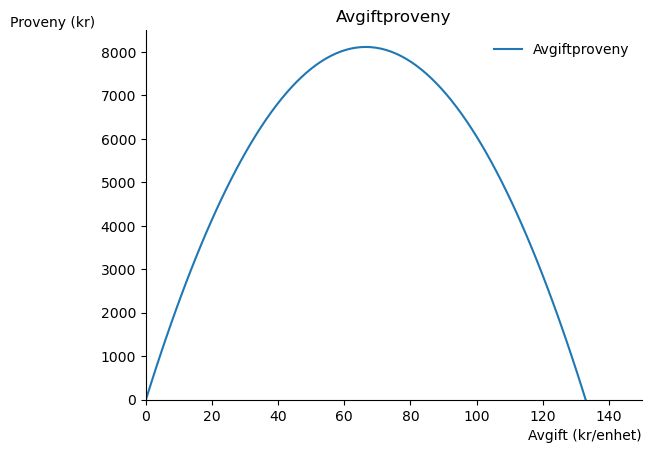

In [61]:
fig,ax=plt.subplots()

ax.set_ylabel('Proveny (kr)', loc = 'top', rotation = 0)
ax.set_xlabel('Avgift (kr/enhet)', loc= 'right')

ax.spines['top'].set_color('none')
ax.spines['right'].set_color('none')

ax.plot(t_num, avgiftprov(t_num),label='Avgiftproveny')



#legend:
ax.legend(loc='best', frameon=False)

#title
ax.set_title ('Avgiftproveny')

ax.set_xlim(0,150)
ax.set_ylim(0,8500);

Denne type kurve kalles ofte en Laffer kurve. (Arthur Laffer var rådgiver for US President Ronald Reagan, 1981-89). Her ser vi myndighetens avveining ganske tydelig, og vi kan også finne avgiftssatsen som maksimerer provenyet.

In [62]:
# finn maks

# deriver mhp t
d_avgpr= sp.diff(avgiftprov(t),t)

# sett = 0 og løs for t

t_opt_dict=sp.solve((d_avgpr,0),t)

t_opt = round(t_opt_dict[t],2)

t_opt

66.50

In [63]:
# maksimal avgiftproveny

maks_prov = round(avgiftprov(t_opt),2)
maks_prov

8112.65

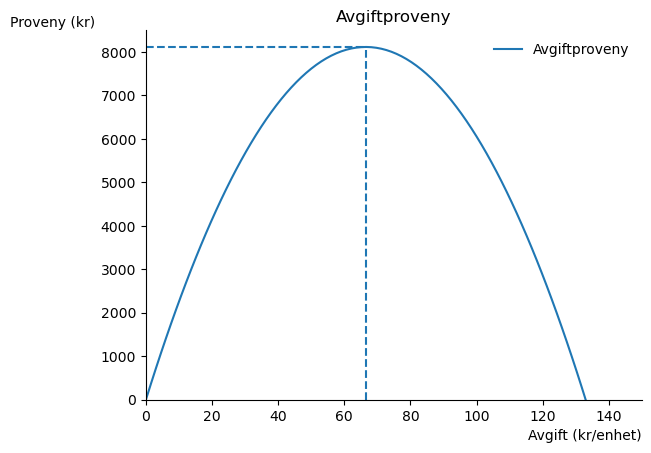

In [64]:
ax.hlines(maks_prov, 0, t_opt, linestyles='dashed')
ax.vlines(t_opt, 0, maks_prov, linestyles='dashed')
fig

La oss nå undersøke likevekten med en avgift i en generell lineær markedsmodell. Vi skal se på en avgift på t kr per enhet som er ilagt produsentene.

In [10]:
import sympy as sp

In [11]:
# definer symbolene som vi kommer til å bruke
Q,P,t,a,b,A,B=sp.symbols('Q p t a b A B', positive=True, real=True)

In [32]:
# Etterspørsel

def Q_E(P,a,b):
    return a - b*(P+t)

#Tilbud

def Q_T(P,A,B,t):
    return -A+B*P

In [33]:
# (i) likevekt
likev=sp.Eq(Q_E(P,a,b),Q_T(P,A,B,t))
likev

Eq(a - b*(P + t), -A + B*P)

In [34]:
# (ii) løsning på produsentpris P_T
eq_E=sp.Eq(Q,Q_E(P,a,b))
eq_T=sp.Eq(Q,Q_T(P,A,B,t))

sol_dict=sp.solve ((eq_E, eq_T), (P,Q))
display(sol_dict[P])
display(sol_dict[Q])

(A + a - b*t)/(B + b)

(-A*b + B*a - B*b*t)/(B + b)

In [37]:
# (iii) pris betalt av konsumenten uten avgift (t=0)

P_0 = sol_dict[P].subs(t,0)
P_0

(A + a)/(B + b)

In [38]:
# andel betalt av konsumenten

andel_k = (sol_dict[P]-P_0)/t

sp.simplify(andel_k)

-b/(B + b)

In [40]:
# alternativt ved bruk av sp.lambdify()
# (iii) pris betalt av konsumenten
P_kons=sp.lambdify((a,b,A,B,t), sol_dict[P])
P_kons(a,b,A,B,t)

(A + a - b*t)/(B + b)

In [41]:
# økning i pris p_T-p_T(t=0)
# andel av økning på konsument = prisøkning/t

andel_kons=sp.simplify((P_kons(a,b,A,B,t)-P_kons(a,b,A,B,0))/t)
andel_kons

-b/(B + b)

(iv) andel betalt av konsumenten er over 0.5 dersom $B>b$. Dvs konsumenter betaler en større andel av avgiften dersom de er mindre følsom for prisendringer enn produsenter. Husk at $\epsilon^D = -b\frac{p}{x}, \epsilon^S=B\frac{p}{x}$. Når vi måler på et felles punkt (dvs samme $\frac{p}{x}$) som likevekten med $t=0$, vil den relative prisfølsomheten bestemmes av sammenlikningen mellom $b$ og $B$.